# Classifying accents using balanced dataset
### SETUP CODE FOR EXPERIMENT 2


In [ ]:
### TODO PLACE GTID HERE:
GTID = "PUT GTID HERE"

In [2]:
import os
base = "/home/hice1/" + GTID + "/scratch/cv-corpus-25.0-2026-03-09"
for f in os.listdir(base):
    print(f)

en


In [3]:
# Common Voice organizes by language; English is usually "en"
en_path = os.path.join(base, "en")
print(os.listdir(en_path))

['reported.tsv', 'invalidated.tsv', 'dev.tsv', 'test.tsv', 'unvalidated_sentences.tsv', 'clips', 'other.tsv', 'train.tsv', 'validated_sentences.tsv', 'clip_durations.tsv', 'README.md', 'validated.tsv']


In [4]:
import pandas as pd
tsv_path = os.path.join(en_path, "validated.tsv")
df = pd.read_csv(tsv_path, sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

/tmp/ipykernel_1160191/2741631514.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_path, sep="\t")


(1880682, 13)
['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,00095e762ba9e83fbffc38d3617aaeaa9bfd94d9f586c5...,common_voice_en_18127094.mp3,3343e59984bbb29777f68734d81dc9a9855b8c40d8b4ac...,"Yes, this is the right place.",NaN,2,0,NaN,NaN,NaN,NaN,en,NaN
1,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,common_voice_en_27710027.mp3,b2cf0b3308b6e00b46f3e48fe59682452ae737a596aa29...,"Joe Keaton disapproved of films, and Buster al...",NaN,3,1,NaN,NaN,NaN,NaN,en,NaN
2,0013037a1d45cc33460806cc3f8ecee9d536c45639ba4c...,common_voice_en_699711.mp3,de9d68400821d73ee6868687d0562c60282ee9446d1191...,She'll be all right.,NaN,2,1,NaN,NaN,NaN,NaN,en,NaN
3,0014c5a3e5715a54855257779b89c2bb498d470b225866...,common_voice_en_21953345.mp3,14c0567a0a6c4ea49f2a1b2ac73de940b8c07779c70bf0...,six,NaN,3,2,NaN,NaN,NaN,NaN,en,Benchmark
4,001519f234e04528a2b36158c205dbe61c8da45ab0242f...,common_voice_en_27340672.mp3,a975540ad0c7ceaaec94cd17ae3b55e1eaf89a61d4a579...,It is a busy market town that serves a large s...,NaN,2,0,NaN,NaN,NaN,NaN,en,NaN


In [5]:
#distribution of accent, age gender
for col in ["accents", "age", "gender"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- accents ---
NaN                                                   843199
United States English                                 447120
England English                                       157679
India and South Asia (India, Pakistan, Sri Lanka)     110842
Canadian English                                       76997
Australian English                                     55498
Non native speaker|German English                      53295
Southern African (South Africa, Zimbabwe, Namibia)     26853
Scottish English                                       19390
New Zealand English                                    15198
Name: accents, dtype: int64

--- age ---
NaN          653901
twenties     457836
thirties     274950
fourties     174586
teens        111598
fifties      107192
sixties       83982
seventies     14535
eighties       1889
nineties        213
Name: age, dtype: int64

--- gender ---
male_masculine        879093
NaN                   691038
female_feminine       310341
do_no

Transcript: Yes, this is the right place.
Accent: nan
Age: nan
Gender: nan
Audio file: /home/hice1/mhasman3/scratch/cv-corpus-25.0-2026-03-09/en/clips/common_voice_en_18127094.mp3
Exists: True
Sample rate: 48000 Hz, Duration: 3.82s


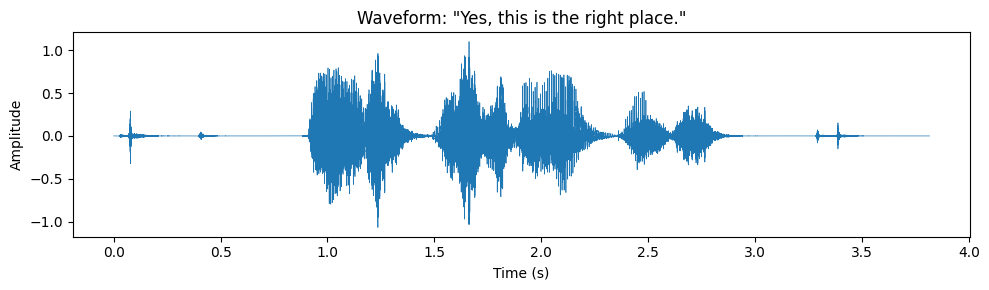

In [6]:
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

clips_dir = os.path.join(en_path, "clips")
row = df.iloc[0]

print("Transcript:", row["sentence"])
print("Accent:", row["accents"])
print("Age:", row["age"])
print("Gender:", row["gender"])
audio_path = os.path.join(clips_dir, row["path"])
print("Audio file:", audio_path)
print("Exists:", os.path.exists(audio_path))

# Load audio
y, sr = sf.read(audio_path)
print(f"Sample rate: {sr} Hz, Duration: {len(y)/sr:.2f}s")

# Play inline
ipd.display(ipd.Audio(y, rate=sr))

# Waveform plot
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Waveform: \"{row['sentence'][:60]}\"")
plt.tight_layout()
plt.show()

In [7]:
# Load all on-disk filenames into a set first — one os.listdir() call instead of millions of exists() checks
on_disk_files = set(os.listdir(clips_dir))

df["on_disk"] = df["path"].apply(lambda p: os.path.basename(p) in on_disk_files)
df_local = df[df["on_disk"]].copy().reset_index(drop=True)
print(f"Clips available locally: {len(df_local)} / {len(df)}")

Clips available locally: 515945 / 1880682


In [8]:
import numpy as np

X            = np.load("/home/hice1/" + GTID + "/scratch/X_that.npy")
y_labels     = np.load("/home/hice1/" + GTID + "/scratch/y_that.npy")
accents_list = np.load("/home/hice1/" + GTID + "/scratch/accents_that.npy", allow_pickle=True)

print(f"X shape      : {X.shape}")
print(f"y shape      : {y_labels.shape}")
print(f"Accents shape: {accents_list.shape}")

X shape      : (78634, 64, 128)
y shape      : (78634,)
Accents shape: (78634,)


### END OF SETUP

In [9]:
# Filter to target accents, merge Canadian → US

accent_map = {
    "United States English": "us",
    "Canadian English": "us",          # merged into US
    "England English": "england",
    "India and South Asia (India, Pakistan, Sri Lanka)": "india",
    "Australian English": "australia",
    "Southern African (South Africa, Zimbabwe, Namibia)": "southern_african",
    "Scottish English": "scottish",
    "New Zealand English": "new_zealand",
    "Irish English": "irish",         
}

df_local["accent_label"] = df_local["accents"].map(accent_map)
df_filtered = df_local[df_local["accent_label"].notna()].copy().reset_index(drop=True)

print(f"Rows after filtering: {len(df_filtered)}")
print("\nClass distribution after merge:")
print(df_filtered["accent_label"].value_counts())

Rows after filtering: 262817

Class distribution after merge:
us                  152749
england              49836
india                21414
australia            19645
new_zealand           7810
scottish              4950
southern_african      3316
irish                 3097
Name: accent_label, dtype: int64


In [10]:
# Build label map, assign integer class IDs

label_map = {
    "australia":        0,
    "england":          1,
    "india":            2,
    "irish":            3,
    "new_zealand":      4,
    "scottish":         5,
    "southern_african": 6,
    "us":               7,
}

df_filtered["label"] = df_filtered["accent_label"].map(label_map)

# Save label map to scratch
import os
os.makedirs("/home/hice1/"+GTID+ "/scratch/accent_splits", exist_ok=True)
pd.DataFrame(list(label_map.items()), columns=["accent", "label_id"]) \
  .to_csv("/home/hice1/"+GTID+"/scratch/accent_splits/label_map.csv", index=False)

print("Label map:")
for accent, idx in sorted(label_map.items(), key=lambda x: x[1]):
    count = (df_filtered["accent_label"] == accent).sum()
    print(f"  {idx}  {accent:<20}  {count:>6} clips")

print(f"\nTotal clips: {len(df_filtered)}")
print(f"Smallest class (irish): 3,097 → this is the per-class cap for balanced training")

Label map:
  0  australia              19645 clips
  1  england                49836 clips
  2  india                  21414 clips
  3  irish                   3097 clips
  4  new_zealand             7810 clips
  5  scottish                4950 clips
  6  southern_african        3316 clips
  7  us                    152749 clips

Total clips: 262817
Smallest class (irish): 3,097 → this is the per-class cap for balanced training


In [11]:
# Train/test split — 200 per class held out for test, remainder available for train

from sklearn.model_selection import train_test_split

TEST_PER_CLASS = 200
SEED = 42

test_frames = []
train_frames = []

for accent, idx in label_map.items():
    cls_df = df_filtered[df_filtered["accent_label"] == accent].copy()
    test_sample = cls_df.sample(n=TEST_PER_CLASS, random_state=SEED)
    train_sample = cls_df.drop(test_sample.index)
    test_frames.append(test_sample)
    train_frames.append(train_sample)

df_test  = pd.concat(test_frames).reset_index(drop=True)
df_train = pd.concat(train_frames).reset_index(drop=True)

print(f"Test set:  {len(df_test)} clips ({TEST_PER_CLASS} per class)")
print(f"\nTrain set class counts (available before balancing):")
train_counts = df_train["accent_label"].value_counts()
print(train_counts)

cap = train_counts.min()
print(f"\nSmallest training class: '{train_counts.idxmin()}' → {cap} clips")
print(f"Balanced training set will have: {cap} × {len(label_map)} = {cap * len(label_map)} total clips")

Test set:  1600 clips (200 per class)

Train set class counts (available before balancing):
us                  152549
england              49636
india                21214
australia            19445
new_zealand           7610
scottish              4750
southern_african      3116
irish                 2897
Name: accent_label, dtype: int64

Smallest training class: 'irish' → 2897 clips
Balanced training set will have: 2897 × 8 = 23176 total clips


In [12]:
# Balance training set and save splits to disk

os.makedirs("/home/hice1/"+GTID+ "/scratch/accent_splits", exist_ok=True)

# Subsample each class to the cap
balanced_frames = []
for accent in label_map.keys():
    cls_df = df_train[df_train["accent_label"] == accent]
    balanced_frames.append(cls_df.sample(n=cap, random_state=SEED))

df_train_balanced = pd.concat(balanced_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Save to disk
df_train_balanced.to_csv("/home/hice1/"+GTID+ "/scratch/accent_splits/train_balanced.csv", index=False)
df_test.to_csv("/home/hice1/"+GTID+ "/scratch/accent_splits/test.csv", index=False)

print(f"Balanced train set: {len(df_train_balanced)} clips")
print(f"Test set:           {len(df_test)} clips")
print(f"\nPer-class counts in balanced train:")
print(df_train_balanced["accent_label"].value_counts().sort_index())
print(f"\nSaved to /home/hice1/"+GTID+ "/scratch/accent_splits/")

Balanced train set: 23176 clips
Test set:           1600 clips

Per-class counts in balanced train:
australia           2897
england             2897
india               2897
irish               2897
new_zealand         2897
scottish            2897
southern_african    2897
us                  2897
Name: accent_label, dtype: int64

Saved to /home/hice1/mhasman3/scratch/accent_splits/


In [13]:
### ONLY RUN CELL FIRST TIME
# Generate mel spectrograms — parallel, cached to disk

import numpy as np
import soundfile as sf
from scipy.signal import stft
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm
import os, warnings

SPEC_DIR   = "/home/hice1/"+GTID+ "/scratch/accent_spectrograms"
CLIPS_DIR  = os.path.join(en_path, "clips")
SR         = 16000
DURATION   = 3.0
N_SAMPLES  = int(SR * DURATION)   # 48000
N_MELS     = 64
N_FFT      = 512
HOP        = 160
N_WORKERS  = 16                   # H200 node has plenty of CPU cores

os.makedirs(SPEC_DIR, exist_ok=True)

# ── Hand-rolled mel filterbank (same as previous runs) ─────────────────────────
def hz_to_mel(h): return 2595 * np.log10(1 + h / 700)
def mel_to_hz(m): return 700 * (10 ** (m / 2595) - 1)

def build_mel_filterbank(sr, n_fft, n_mels):
    low, high = hz_to_mel(0), hz_to_mel(sr / 2)
    mel_pts   = np.linspace(low, high, n_mels + 2)
    hz_pts    = mel_to_hz(mel_pts)
    bins      = np.floor(hz_pts / (sr / n_fft)).astype(int)
    fb        = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for m in range(1, n_mels + 1):
        l, c, r = bins[m-1], bins[m], bins[m+1]
        if c > l: fb[m-1, l:c] = (np.arange(l, c) - l) / (c - l)
        if r > c: fb[m-1, c:r] = (r - np.arange(c, r)) / (r - c)
    return fb

MEL_FB = build_mel_filterbank(SR, N_FFT, N_MELS)  # (64, 257)

# ── Per-clip processing function (runs in worker process) ─────────────────────
def process_clip(args):
    path, out_path = args
    if os.path.exists(out_path):
        return "cached"
    try:
        y, sr = sf.read(path, always_2d=False)
        if y.ndim == 2:
            y = y.mean(axis=1)                        # stereo → mono
        if sr != SR:
            # simple resample via repeat/drop (crude but fast; clips are near 16kHz)
            y = np.interp(
                np.linspace(0, len(y), int(len(y) * SR / sr)),
                np.arange(len(y)), y
            ).astype(np.float32)
        # Pad or trim to exactly 3 s
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)))
        else:
            y = y[:N_SAMPLES]
        # STFT
        _, _, Z = stft(y, fs=SR, nperseg=N_FFT, noverlap=N_FFT - HOP)
        power = np.abs(Z).astype(np.float32) ** 2      # (257, T)
        mel   = MEL_FB @ power                          # (64, T)
        mel   = np.log(mel + 1e-9)                      # log scale
        # Trim/pad time axis to exactly 188 frames
        if mel.shape[1] >= 188:
            mel = mel[:, :188]
        else:
            mel = np.pad(mel, ((0,0),(0, 188 - mel.shape[1])))
        np.save(out_path, mel.astype(np.float32))
        return "ok"
    except Exception as e:
        return f"err:{e}"

# ── Build job list (train + test, deduplicated by filename) ───────────────────
all_clips = pd.concat([df_train_balanced, df_test]).drop_duplicates(subset="path")
jobs = []
for _, row in all_clips.iterrows():
    fname    = os.path.basename(row["path"])
    out_path = os.path.join(SPEC_DIR, fname.replace(".mp3", ".npy"))
    in_path  = os.path.join(CLIPS_DIR, fname)
    jobs.append((in_path, out_path))

print(f"Total clips to process: {len(jobs)}")
already  = sum(1 for _, o in jobs if os.path.exists(o))
print(f"Already cached:         {already}")
print(f"To generate:            {len(jobs) - already}")

# ── Run parallel workers ──────────────────────────────────────────────────────
results = {"ok": 0, "cached": 0, "err": 0}
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(process_clip, j): j for j in jobs}
    with tqdm(total=len(jobs), desc="Spectrograms", unit="clip") as pbar:
        for fut in as_completed(futures):
            r = fut.result()
            if r == "ok":       results["ok"]     += 1
            elif r == "cached": results["cached"] += 1
            else:               results["err"]    += 1
            pbar.set_postfix(results, refresh=False)
            pbar.update(1)

print(f"\nDone. Generated: {results['ok']}  Cached: {results['cached']}  Errors: {results['err']}")

Total clips to process: 24776
Already cached:         24776
To generate:            0


Spectrograms:   0%|          | 0/24776 [00:00<?, ?clip/s]


Done. Generated: 0  Cached: 24776  Errors: 0


In [14]:
# Verify cached spectrograms exist
import os
import pandas as pd

SPEC_DIR = "/home/hice1/"+GTID+ "/scratch/accent_spectrograms"

# Ensure your dataframes are loaded from the previous CSV saves
# (Run this if you haven't re-run the split cells yet)
if 'df_train_balanced' not in locals():
    df_train_balanced = pd.read_csv("/home/hice1/"+GTID+ "/scratch/accent_splits/train_balanced.csv")
if 'df_test' not in locals():
    df_test = pd.read_csv("/home/hice1/"+GTID+ "/scratch/accent_splits/test.csv")

# Verify cache status
all_paths = pd.concat([df_train_balanced["path"], df_test["path"]]).unique()
expected_files = [os.path.basename(p).replace(".mp3", ".npy") for p in all_paths]
existing_files = set(os.listdir(SPEC_DIR))

found = sum(1 for f in expected_files if f in existing_files)
print(f"Cache check: {found} / {len(expected_files)} spectrograms found in scratch.")
if found == len(expected_files):
    print("Verification complete. Ready for training.")
else:
    print(f"Warning: {len(expected_files) - found} files missing. You may need to re-run the full Cell 11.")

Cache check: 24776 / 24776 spectrograms found in scratch.
Verification complete. Ready for training.


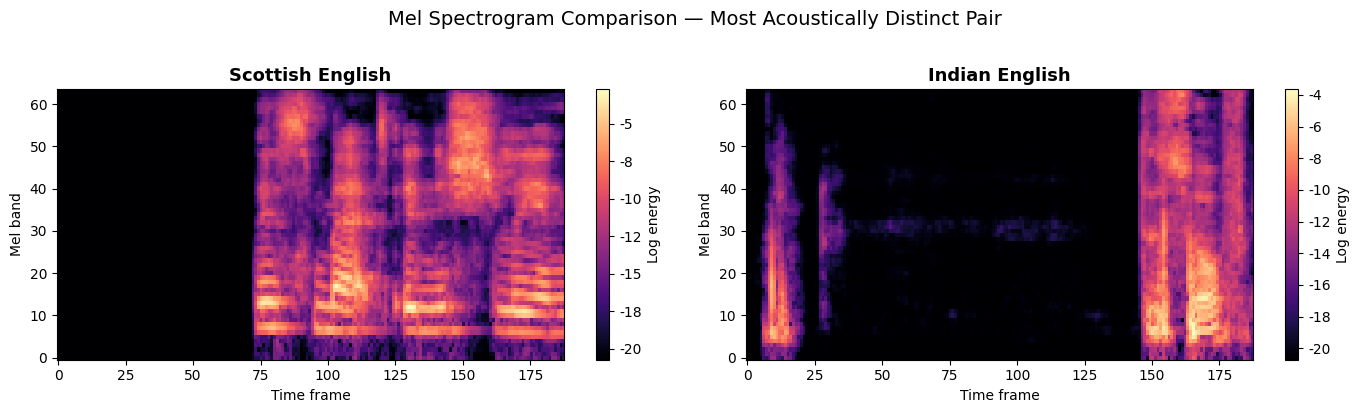

In [15]:
# Plot mel spectrograms for Scottish vs Indian English

import matplotlib.pyplot as plt
import numpy as np

def plot_spec(ax, spec_path, title):
    mel = np.load(spec_path)
    im = ax.imshow(mel, aspect="auto", origin="lower",
                   cmap="magma", interpolation="nearest")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel band")
    plt.colorbar(im, ax=ax, format="%.0f", label="Log energy")

# Grab one example from each accent
def get_spec_path(accent_label):
    row = df_train_balanced[df_train_balanced["accent_label"] == accent_label].iloc[0]
    fname = os.path.basename(row["path"]).replace(".mp3", ".npy")
    return os.path.join(SPEC_DIR, fname)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_spec(axes[0], get_spec_path("scottish"), "Scottish English")
plot_spec(axes[1], get_spec_path("india"),    "Indian English")

plt.suptitle("Mel Spectrogram Comparison — Most Acoustically Distinct Pair",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# PyTorch Dataset and DataLoaders
import sys
import os

# MANDATORY: Remove .local from path BEFORE importing torch to avoid version conflicts
sys.path = [p for p in sys.path if ".local" not in p]

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

SPEC_DIR = "/home/hice1/"+GTID+ "/scratch/accent_spectrograms"

class AccentDataset(Dataset):
    def __init__(self, df, spec_dir):
        self.spec_dir = spec_dir
        records = []
        # Optimization: use a set for faster lookups if disk is slow
        available_files = set(os.listdir(spec_dir))
        
        for _, row in df.iterrows():
            fname = os.path.basename(row["path"]).replace(".mp3", ".npy")
            if fname in available_files:
                fpath = os.path.join(spec_dir, fname)
                records.append((fpath, int(row["label"])))
        
        self.records = records
        print(f"  Dataset: {len(records)} / {len(df)} clips found on disk")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        fpath, label = self.records[idx]
        mel = np.load(fpath)                          # (64, 188) float32
        # Ensure we return a float tensor
        mel = torch.from_numpy(mel).unsqueeze(0).float() # (1, 64, 188)
        return mel, label

# Build datasets
print("Building datasets...")
train_dataset = AccentDataset(df_train_balanced, SPEC_DIR)
test_dataset  = AccentDataset(df_test,           SPEC_DIR)

# DataLoaders — optimized for H200 (high throughput)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Sanity check
batch_x, batch_y = next(iter(train_loader))
print(f"\nSample batch — X: {batch_x.shape}, y: {batch_y.shape}")
print(f"Label distribution in batch: {dict(zip(*torch.unique(batch_y, return_counts=True)))}")

Building datasets...
  Dataset: 23176 / 23176 clips found on disk
  Dataset: 1600 / 1600 clips found on disk

Train batches: 363
Test batches:  25


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(



Sample batch — X: torch.Size([64, 1, 64, 188]), y: torch.Size([64])
Label distribution in batch: {tensor(0): tensor(11), tensor(1): tensor(8), tensor(2): tensor(7), tensor(3): tensor(7), tensor(4): tensor(10), tensor(5): tensor(7), tensor(6): tensor(6), tensor(7): tensor(8)}


In [17]:
# Define the AccentCNN Architecture
import sys
# Ensure we don't pick up conflicting local packages on PACE
sys.path = [p for p in sys.path if ".local" not in p]

import torch.nn as nn
import torch.nn.functional as F

class AccentCNN(nn.Module):
    def __init__(self, num_classes=8): # Adjusted for our 8 classes
        super().__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # Output: (32, 32, 94)
            nn.Dropout2d(0.25)
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # Output: (64, 16, 47)
            nn.Dropout2d(0.25)
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # Output: (128, 8, 23)
            nn.Dropout2d(0.25)
        )
        
        # Global average pool
        self.gap = nn.AdaptiveAvgPool2d(1)  # Output: (128, 1, 1)
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# Initialize and print parameter count
model = AccentCNN(num_classes=8)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized with {total_params:,} parameters.")

Model initialized with 296,104 parameters.


In [18]:
# Training and Evaluation Functions
import torch.optim as optim
from tqdm.notebook import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Using Unweighted CrossEntropy for Run 3 to test data balancing effect
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="  Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix(loss=running_loss/len(pbar), acc=100.*correct/total)
        
    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader), 100. * correct / total

print(f"Functions defined. Model is on: {device}")

Functions defined. Model is on: cuda


In [19]:
# Main Training Loop
NUM_EPOCHS = 20
BEST_MODEL_PATH = "/home/hice1/"+GTID+ "/scratch/accent_model_run3_balanced.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

print(f"Starting Run 3: Balanced Training (Cap={cap})")
print("-" * 30)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()
    
    # Train and Evaluate
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)
    
    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    duration = time.time() - start_time
    
    print(f"Epoch {epoch}/{NUM_EPOCHS} [{duration:.1f}s]: "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Checkpoint best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'label_map': label_map
        }, BEST_MODEL_PATH)
        print(f"  --> New Best Model Saved ({best_acc:.2f}%)")

print("-" * 30)
print(f"Training Complete. Best Validation Accuracy: {best_acc:.2f}%")

Starting Run 3: Balanced Training (Cap=2897)
------------------------------


  Training:   0%|          | 0/363 [00:00<?, ?it/s]

Epoch 1/20 [20.6s]: Train Loss: 2.0489 | Train Acc: 17.29% | Val Loss: 2.0055 | Val Acc: 22.62%
  --> New Best Model Saved (22.62%)


  Training:   0%|          | 0/363 [00:00<?, ?it/s]

Epoch 2/20 [3.8s]: Train Loss: 1.9762 | Train Acc: 22.71% | Val Loss: 1.9356 | Val Acc: 28.25%
  --> New Best Model Saved (28.25%)


...

Epoch 18/20 [3.8s]: Train Loss: 1.5429 | Train Acc: 43.66% | Val Loss: 1.5275 | Val Acc: 44.25%


  Training:   0%|          | 0/363 [00:00<?, ?it/s]

Epoch 19/20 [3.8s]: Train Loss: 1.5313 | Train Acc: 43.82% | Val Loss: 1.4766 | Val Acc: 47.00%
  --> New Best Model Saved (47.00%)


  Training:   0%|          | 0/363 [00:00<?, ?it/s]

Epoch 20/20 [3.8s]: Train Loss: 1.5231 | Train Acc: 44.34% | Val Loss: 1.4855 | Val Acc: 46.19%
------------------------------
Training Complete. Best Validation Accuracy: 47.00%


Run 3: Balanced Training Performance

                  precision    recall  f1-score   support

       australia       0.61      0.46      0.52       200
         england       0.28      0.36      0.31       200
           india       0.40      0.42      0.41       200
           irish       0.40      0.66      0.50       200
     new_zealand       0.69      0.78      0.73       200
        scottish       0.89      0.61      0.73       200
southern_african       0.36      0.37      0.36       200
              us       0.26      0.10      0.14       200

        accuracy                           0.47      1600
       macro avg       0.49      0.47      0.46      1600
    weighted avg       0.49      0.47      0.46      1600



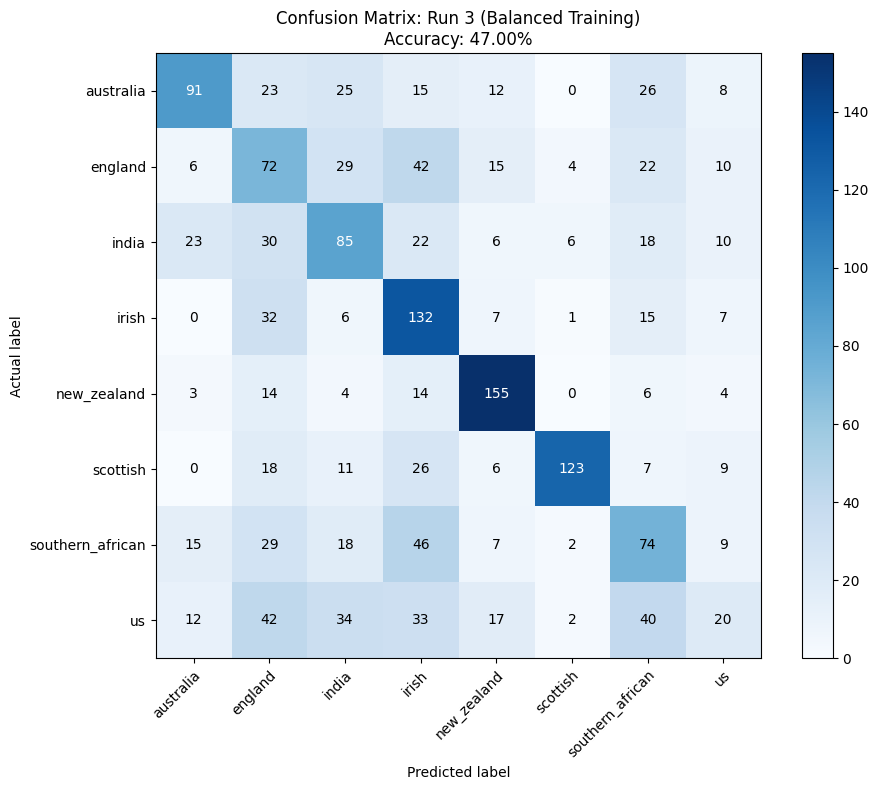

In [20]:
# Final Evaluation & Per-Class Accuracy
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load the best model from the run
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Map integer IDs back to names for the report
target_names = [name for name, idx in sorted(label_map.items(), key=lambda x: x[1])]

print("Run 3: Balanced Training Performance\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot Confusion Matrix using Matplotlib
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set ticks and labels
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=target_names, yticklabels=target_names,
       title=f'Confusion Matrix: Run 3 (Balanced Training)\nAccuracy: {checkpoint["val_acc"]:.2f}%',
       ylabel='Actual label',
       xlabel='Predicted label')

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.show()

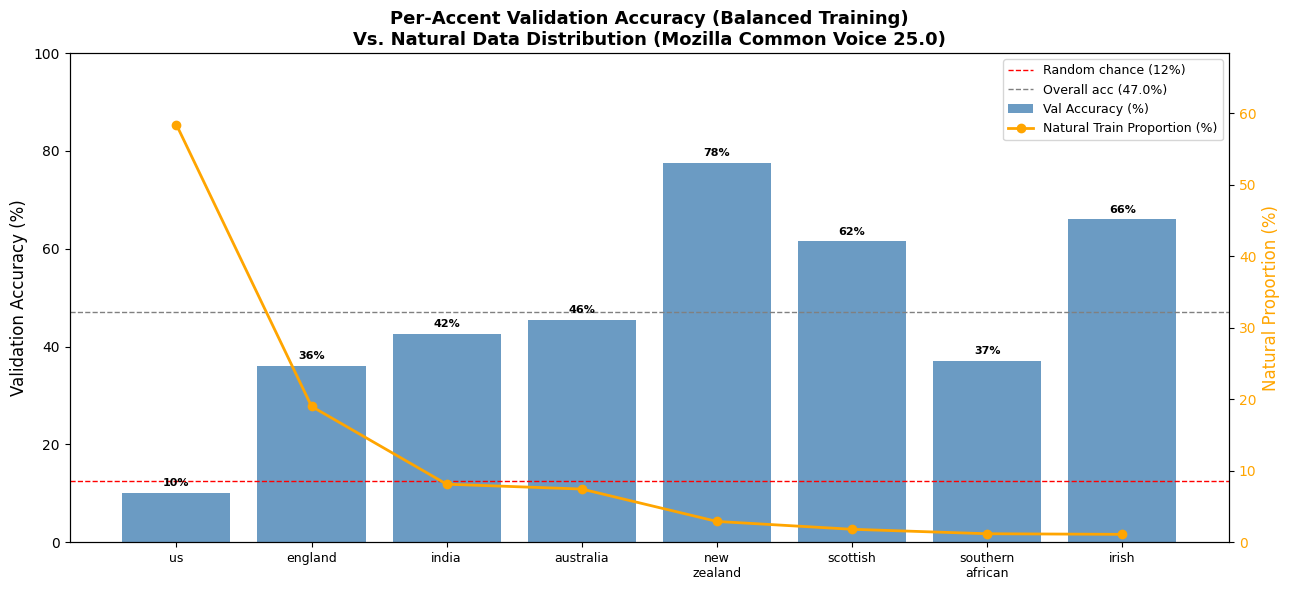


Plot saved to /home/hice1/mhasman3/scratch/per_accent_accuracy_balanced_run.png


In [21]:
# Generate Accuracy vs. Natural Proportion Plot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Calculate Per-Class Accuracy from Run 3
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
overall_acc3 = accuracy_score(y_true, y_pred)

# 2. Get the Natural Proportions (from the pre-balanced training set)
# Using the counts from Cell 9
natural_counts = {
    "us": 152549, "england": 49636, "india": 21214, "australia": 19445,
    "new_zealand": 7610, "scottish": 4750, "southern_african": 3116, "irish": 2897
}
total_natural = sum(natural_counts.values())
natural_pcts = {k: (v / total_natural) * 100 for k, v in natural_counts.items()}

# 3. Prepare data for plotting
results3 = []
for accent, idx in label_map.items():
    results3.append({
        "accent": accent,
        "acc": per_class_acc[idx],
        "train_pct": natural_pcts[accent] # Using natural pct for the trend line
    })

# Sort by natural training proportion (Descending)
results_sorted3 = sorted(results3, key=lambda x: x["train_pct"], reverse=True)

accents3    = [r["accent"].replace("_", "\n") for r in results_sorted3]
accs3       = [r["acc"] * 100 for r in results_sorted3]
train_pcts3 = [r["train_pct"] for r in results_sorted3]
NUM_CLASSES = len(label_map)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(accents3))

# Primary Axis: Accuracy (Bars)
bars = ax1.bar(x, accs3, color="steelblue", alpha=0.8, label="Val Accuracy (%)")

# Reference Lines
ax1.axhline(100/NUM_CLASSES, color="red", linestyle="--", linewidth=1, 
            label=f"Random chance ({100/NUM_CLASSES:.0f}%)")
ax1.axhline(overall_acc3 * 100, color="gray", linestyle="--", linewidth=1, 
            label=f"Overall acc ({overall_acc3:.1%})")

ax1.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(accents3, fontsize=9)

# Secondary Axis: Natural Proportion (Line)
ax2 = ax1.twinx()
ax2.plot(x, train_pcts3, color="orange", marker="o", linewidth=2, markersize=6, 
         label="Natural Train Proportion (%)")
ax2.set_ylabel("Natural Proportion (%)", fontsize=12, color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.set_ylim(0, max(train_pcts3) + 10)

# Add value labels on top of bars
for bar, acc in zip(bars, accs3):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{acc:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

ax1.set_title(
    "Per-Accent Validation Accuracy (Balanced Training)\n"
    "Vs. Natural Data Distribution (Mozilla Common Voice 25.0)",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plot_path3 = "/home/hice1/"+GTID+ "/scratch/per_accent_accuracy_balanced_run.png"
plt.savefig(plot_path3, dpi=150)
plt.show()

print(f"\nPlot saved to {plot_path3}")

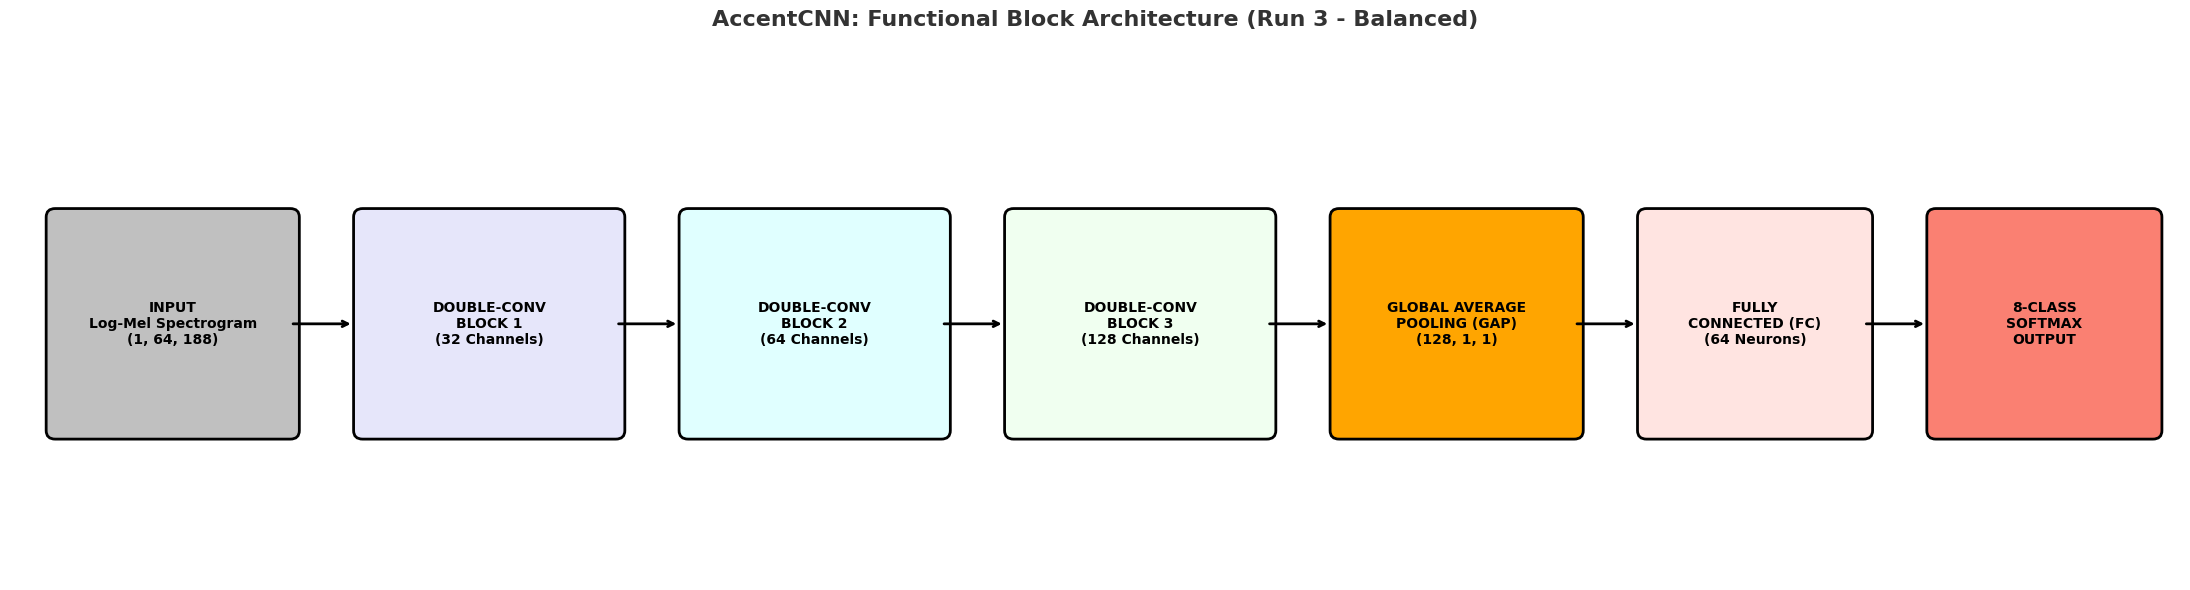

Diagram saved to: /home/hice1/mhasman3/scratch/accent_cnn_precise_tall.png


In [22]:
### Code for generating image of neural network

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_accent_cnn_precise_tall():
    # Same width (22), but height increased to 6 for better legibility
    fig, ax = plt.subplots(figsize=(22, 6))
    
    # X: 0->24, Y: 0->6
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # --- Precise Drawing Helpers ---
    
    def draw_precise_block(x, y, text, color, width=2.8, height=2.5):
        box = patches.FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.1", 
                                     linewidth=2.0, edgecolor="black", facecolor=color)
        ax.add_patch(box)
        # Font size increased slightly since we have more vertical space
        ax.text(x + width/2, y + height/2, text, ha='center', va='center', 
                fontsize=10, fontweight='bold', wrap=True)
        return x + width

    def draw_precise_arrow(x, y=3.0, label=""):
        ax.annotate('', xy=(x + 0.7, y), xytext=(x, y),
                    arrowprops=dict(arrowstyle='->', lw=2.0, color='black'))
        if label:
            ax.text(x + 0.35, y + 0.2, label, ha='center', fontsize=9, fontweight='bold', color='navy')
        return x + 0.8

    # --- Sequential Drawing (Vertical Center is Y=1.75) ---
    curr_x = 0.5
    y_center = 1.75
    
    # 1. INPUT
    curr_x = draw_precise_block(curr_x, y_center, "INPUT\nLog-Mel Spectrogram\n(1, 64, 188)", "silver", width=2.6)
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    # 2. FEATURE EXTRACTORS (Double-Convolutional Blocks)
    # Added spatial resolution labels to the arrows to show downsampling
    curr_x = draw_precise_block(curr_x, y_center, "DOUBLE-CONV\nBLOCK 1\n(32 Channels)", "lavender")
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    curr_x = draw_precise_block(curr_x, y_center, "DOUBLE-CONV\nBLOCK 2\n(64 Channels)", "lightcyan")
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    curr_x = draw_precise_block(curr_x, y_center, "DOUBLE-CONV\nBLOCK 3\n(128 Channels)", "honeydew")
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    # 3. DECISION & CLASSIFIER HEAD
    curr_x = draw_precise_block(curr_x, y_center, "GLOBAL AVERAGE\nPOOLING (GAP)\n(128, 1, 1)", "orange", width=2.6)
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    curr_x = draw_precise_block(curr_x, y_center, "FULLY\nCONNECTED (FC)\n(64 Neurons)", "mistyrose", width=2.4)
    curr_x = draw_precise_arrow(curr_x, y=y_center+1.25)
    
    # 4. OUTPUT
    draw_precise_block(curr_x, y_center, "8-CLASS\nSOFTMAX\nOUTPUT", "salmon", width=2.4)

    plt.title("AccentCNN: Functional Block Architecture (Run 3 - Balanced)", 
              fontsize=16, fontweight='bold', color="#333333", pad=30)
    
    plt.tight_layout()
    
    save_path = "/home/hice1/" + GTID + "/scratch/accent_cnn_precise_tall.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

    print(f"Diagram saved to: {save_path}")

draw_accent_cnn_precise_tall()

In [23]:
# ── F1 Scores ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import f1_score

# Re-run inference to get predictions
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

f1_per_class = f1_score(y_true, y_pred, average=None)
f1_macro     = f1_score(y_true, y_pred, average="macro")
f1_weighted  = f1_score(y_true, y_pred, average="weighted")

print("=" * 45)
print(f"{'Accent':<22} {'F1 Score':>10}")
print("=" * 45)
for accent, idx in sorted(label_map.items(), key=lambda x: x[1]):
    print(f"  {accent:<22} {f1_per_class[idx]:>10.4f}")
print("=" * 45)
print(f"  {'Macro F1':<22} {f1_macro:>10.4f}")
print(f"  {'Weighted F1':<22} {f1_weighted:>10.4f}")
print("=" * 45)

Accent                   F1 Score
  australia                  0.5200
  england                    0.3130
  india                      0.4126
  irish                      0.4981
  new_zealand                0.7294
  scottish                   0.7278
  southern_african           0.3627
  us                         0.1444
  Macro F1                   0.4635
  Weighted F1                0.4635


### END OF EXPERIMENT 2